<a href="https://colab.research.google.com/github/vtminc1000/Analisis-Sentimen/blob/main/Uji1kalimat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas openpyxl transformers torch vaderSentiment textblob deep-translator matplotlib -q

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt

from google.colab import files
from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from deep_translator import GoogleTranslator

In [ ]:
uploaded = files.upload()

Saving Data_Inite.xlsx to Data_Inite (1).xlsx


In [ ]:
uploaded = files.upload()

Saving positive.tsv.txt to positive.tsv (1).txt


In [ ]:
uploaded = files.upload()

Saving negative.tsv.txt to negative.tsv (2).txt


In [ ]:
df = pd.read_excel('Data_Inite.xlsx')
positive = pd.read_csv('positive.tsv.txt', sep='\t')
negative = pd.read_csv('negative.tsv.txt', sep='\t')

print(df.head())
print(positive.head())
print(negative.head())

   responden_id                                             pre_q1  \
0             1  Segala sesuatu yang berkaitan dengan inti atom...   
1             2                                                Bom   
2             3  Sesuatu tentang kimia yg bisa digunakan untuk ...   
3             4  Suatu material yang tidak terlihat dan tidak b...   
4             5                                    \nenergi bersih   

   pre_q1_label                                             pre_q2  \
0             0                                       Sebagai PLTN   
1            -1                                Sumber daya listrik   
2             1                         Untuk tenaga atau uji coba   
3             0  Sebagai pembangkit listrik, karena bisa diguna...   
4             1  Teknologi dalam lapangan medic, seperti ct sca...   

   pre_q2_label                                            post_q1  \
0             1  Menurut saya, ini bukan sesuatu yang dapat dit...   
1             1  K

In [ ]:
data_long = []

for _, row in df.iterrows():
    data_long.append({
        'responden_id': row['responden_id'],
        'tahap': 'pre',
        'pertanyaan': 'q1',
        'teks': row['pre_q1'],
        'label_asli': row['pre_q1_label']
    })
    data_long.append({
        'responden_id': row['responden_id'],
        'tahap': 'pre',
        'pertanyaan': 'q2',
        'teks': row['pre_q2'],
        'label_asli': row['pre_q2_label']
    })
    data_long.append({
        'responden_id': row['responden_id'],
        'tahap': 'post',
        'pertanyaan': 'q1',
        'teks': row['post_q1'],
        'label_asli': row['post_q1_label']
    })
    data_long.append({
        'responden_id': row['responden_id'],
        'tahap': 'post',
        'pertanyaan': 'q2',
        'teks': row['post_q2'],
        'label_asli': row['post_q2_label']
    })

data_long = pd.DataFrame(data_long)
data_long.head(10)

,responden_id,tahap,pertanyaan,teks,label_asli
0,1,pre,q1,Segala sesuatu yang berkaitan dengan inti atom...,0
1,1,pre,q2,Sebagai PLTN,1
2,1,post,q1,"Menurut saya, ini bukan sesuatu yang dapat dit...",1
3,1,post,q2,Dapat menjadi PLTN,1
4,2,pre,q1,Bom,-1
5,2,pre,q2,Sumber daya listrik,1
6,2,post,q1,Kekuatan yang terkandung di dalam inti atom me...,0
7,2,post,q2,"untuk menghasilkan listrik, diagnosis dan peng...",1
8,3,pre,q1,Sesuatu tentang kimia yg bisa digunakan untuk ...,1
9,3,pre,q2,Untuk tenaga atau uji coba,1


In [ ]:
kalimat_uji = "untuk pembangkit listrik tenaga nuklir"
label_manual = 1

In [ ]:
df_uji = pd.DataFrame({
    'teks': [kalimat_uji],
    'label_manual': [label_manual]
})

df_uji

,teks,label_manual
0,untuk pembangkit listrik tenaga nuklir,1


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_uji['teks_clean'] = df_uji['teks'].apply(clean_text)
df_uji

,teks,label_manual,teks_clean
0,untuk pembangkit listrik tenaga nuklir,1,untuk pembangkit listrik tenaga nuklir


In [ ]:
lexicon_df = pd.concat([positive, negative], ignore_index=True)
inset_dict = dict(zip(lexicon_df['word'], lexicon_df['weight']))
list(inset_dict.items())[:10]

[('hai', 3),
 ('merekam', 2),
 ('ekstensif', 3),
 ('paripurna', 1),
 ('detail', 2),
 ('pernik', 3),
 ('belas', -3),
 ('welas', -3),
 ('kabung', -5),
 ('rahayu', -2)]

In [ ]:
def inset_predict(text):
    score = 0
    words = str(text).split()

    for word in words:
        if word in inset_dict:
            score += inset_dict[word]

    if score > 0:
        return 1
    elif score < 0:
        return -1
    else:
        return 0

In [ ]:
classifier = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def indobert_predict(text):
    result = classifier(str(text))[0]
    label = result['label'].lower()

    if label == 'negative':
        return -1
    elif label == 'neutral':
        return 0
    else:
        return 1

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def translate_text(text):
    try:
        return GoogleTranslator(source='id', target='en').translate(str(text))
    except:
        return str(text)

def vader_predict(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 1
    elif score <= -0.05:
        return -1
    else:
        return 0

In [ ]:
def textblob_predict(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0:
        return 1
    elif polarity < 0:
        return -1
    else:
        return 0

In [ ]:
df_uji['inset'] = df_uji['teks_clean'].apply(inset_predict)
df_uji['indobert'] = df_uji['teks_clean'].apply(indobert_predict)
df_uji['teks_en'] = df_uji['teks_clean'].apply(translate_text)
df_uji['vader'] = df_uji['teks_en'].apply(vader_predict)
df_uji['textblob'] = df_uji['teks_en'].apply(textblob_predict)

df_uji

,teks,label_manual,teks_clean,inset,indobert,teks_en,vader,textblob
0,untuk pembangkit listrik tenaga nuklir,1,untuk pembangkit listrik tenaga nuklir,1,0,for nuclear power plants,0,0


In [ ]:
df_plot = pd.DataFrame({
    'Metode': ['Manual', 'InSet', 'IndoBERT', 'VADER', 'TextBlob'],
    'Nilai': [
        df_uji.loc[0, 'label_manual'],
        df_uji.loc[0, 'inset'],
        df_uji.loc[0, 'indobert'],
        df_uji.loc[0, 'vader'],
        df_uji.loc[0, 'textblob']
    ]
})

df_plot

,Metode,Nilai
0,Manual,-1
1,InSet,-1
2,IndoBERT,0
3,VADER,-1
4,TextBlob,-1


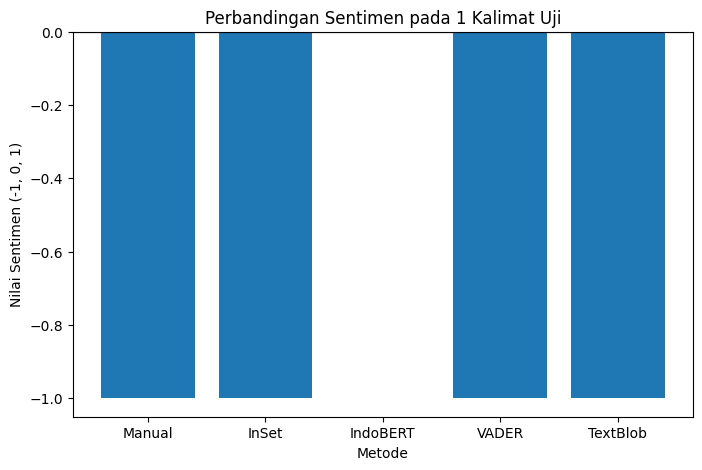

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df_plot['Metode'], df_plot['Nilai'])

plt.title('Perbandingan Sentimen pada 1 Kalimat Uji')
plt.xlabel('Metode')
plt.ylabel('Nilai Sentimen (-1, 0, 1)')
plt.axhline(0, color='black', linewidth=0.8)

plt.show()

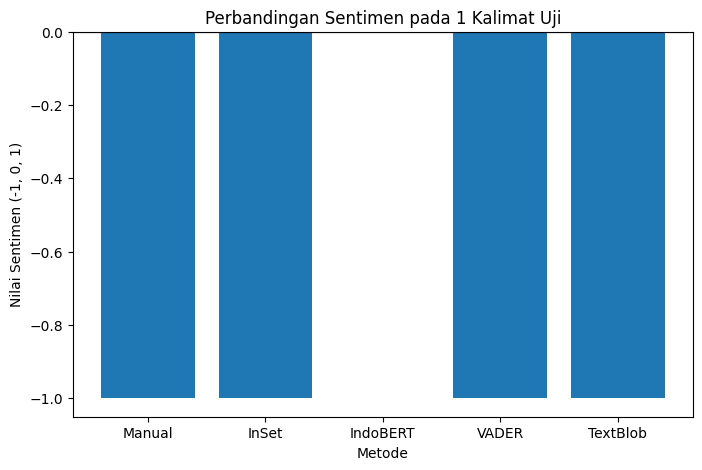

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df_plot['Metode'], df_plot['Nilai'])

plt.title('Perbandingan Sentimen pada 1 Kalimat Uji')
plt.xlabel('Metode')
plt.ylabel('Nilai Sentimen (-1, 0, 1)')
plt.axhline(0, color='black', linewidth=0.8)

plt.savefig('grafik_1_kalimat_uji.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df_uji.to_excel('hasil_1_kalimat_uji.xlsx', index=False)
df_plot.to_excel('ringkasan_1_kalimat_uji.xlsx', index=False)

files.download('hasil_1_kalimat_uji.xlsx')
files.download('ringkasan_1_kalimat_uji.xlsx')
files.download('grafik_1_kalimat_uji.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>